# Handwritten Character Recognition using Machine Learning
**Project Title**: Handwritten Character Recognition using Machine Learning (MNIST)  
**Objective**: Build a machine learning model that recognizes handwritten digits (0–9) using the MNIST dataset.

## Phase 1: Data Collection & Library Imports
In this phase, we import required Python libraries and load the training (`train.csv`) and testing (`test.csv`) dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Load Dataset
train = pd.read_csv("dataset/train.csv")
test = pd.read_csv("dataset/test.csv")

print("Training Dataset Shape:", train.shape)
print("Testing Dataset Shape: ", test.shape)

train.head()

Training Dataset Shape: (10000, 785)
Testing Dataset Shape:  (2000, 785)


## Phase 2: Data Preprocessing
Extract features and target labels, and normalize pixel values from `[0, 255]` to `[0.0, 1.0]`.

In [2]:
# Separate features (pixels) and target labels
X = train.iloc[:, 1:].values
y = train.iloc[:, 0].values

X_test = test.iloc[:, 1:].values
y_test = test.iloc[:, 0].values

# Normalize pixel values
X = X / 255.0
X_test = X_test / 255.0

print("Normalized X Range:", X.min(), "to", X.max())

Normalized X Range: 0.0 to 1.0


## Phase 3: Data Visualization
Display sample handwritten digit images from the dataset.

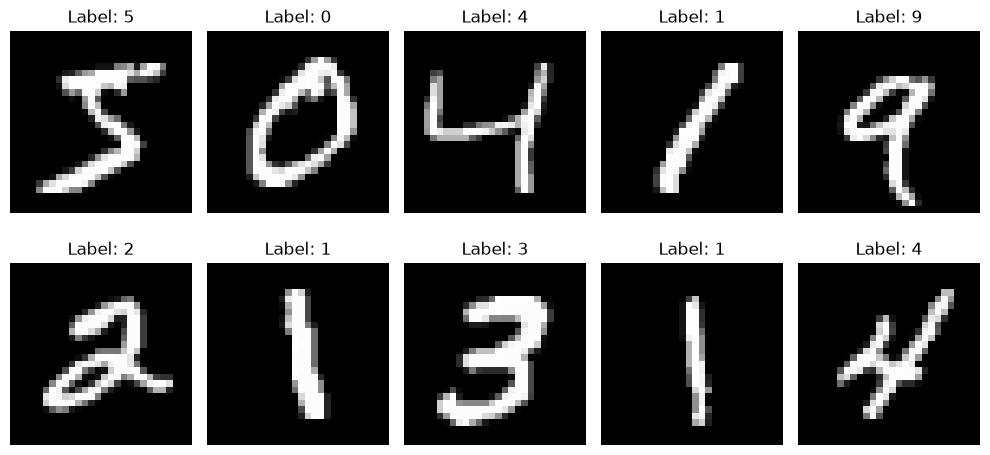

In [3]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Phase 4 & 5: Model Building & Model Training
Build a Multi-Layer Perceptron (MLP) Neural Network classifier with hidden layers `(128, 64)` and train on the training data.

In [4]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    max_iter=25,
    activation='relu',
    solver='adam',
    random_state=42,
    verbose=True
)

model.fit(X_train, y_train)

Iteration 1, loss = 1.12396652
Iteration 2, loss = 0.37276641
Iteration 3, loss = 0.27625812
Iteration 4, loss = 0.22594491
Iteration 5, loss = 0.18783273
Iteration 6, loss = 0.16016693
Iteration 7, loss = 0.13806836
Iteration 8, loss = 0.11898533
Iteration 9, loss = 0.10260017
Iteration 10, loss = 0.09008725
Iteration 11, loss = 0.07869912
Iteration 12, loss = 0.06647834
Iteration 13, loss = 0.05670674
Iteration 14, loss = 0.04993698
Iteration 15, loss = 0.04282579
Iteration 16, loss = 0.03591601
Iteration 17, loss = 0.03221191
Iteration 18, loss = 0.03209773
Iteration 19, loss = 0.02445693
Iteration 20, loss = 0.02058703
Iteration 21, loss = 0.01794950
Iteration 22, loss = 0.01527686
Iteration 23, loss = 0.01304277
Iteration 24, loss = 0.01175685
Iteration 25, loss = 0.01037578


## Phase 6 & 7: Model Testing & Performance Evaluation
Evaluate trained model performance on unseen test data using Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.

In [5]:
test_preds = model.predict(X_test)

acc = accuracy_score(y_test, test_preds)
prec = precision_score(y_test, test_preds, average='macro')
rec = recall_score(y_test, test_preds, average='macro')
f1 = f1_score(y_test, test_preds, average='macro')

print("="*45)
print("     PERFORMANCE EVALUATION METRICS     ")
print("="*45)
print(f"Accuracy:  {acc*100:.2f}%")
print(f"Precision: {prec*100:.2f}%")
print(f"Recall:    {rec*100:.2f}%")
print(f"F1-Score:  {f1*100:.2f}%")
print("="*45)
print("\nClassification Report:\n", classification_report(y_test, test_preds))

     PERFORMANCE EVALUATION METRICS     
Accuracy:  95.20%
Precision: 95.14%
Recall:    95.14%
F1-Score:  95.12%

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       205
           1       0.97      0.98      0.97       224
           2       0.92      0.97      0.94       185
           3       0.95      0.89      0.92       196
           4       0.95      0.97      0.96       204
           5       0.96      0.95      0.95       185
           6       0.97      0.97      0.97       194
           7       0.97      0.95      0.96       209
           8       0.91      0.92      0.91       183
           9       0.95      0.96      0.95       215

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000



## Phase 8 & 9: Visualizing Predictions & Results
Plot Training Loss Curve, Confusion Matrix, and Sample Handwritten Digit Predictions.

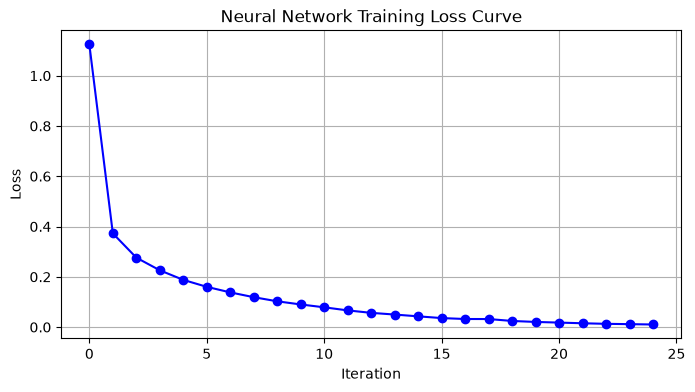

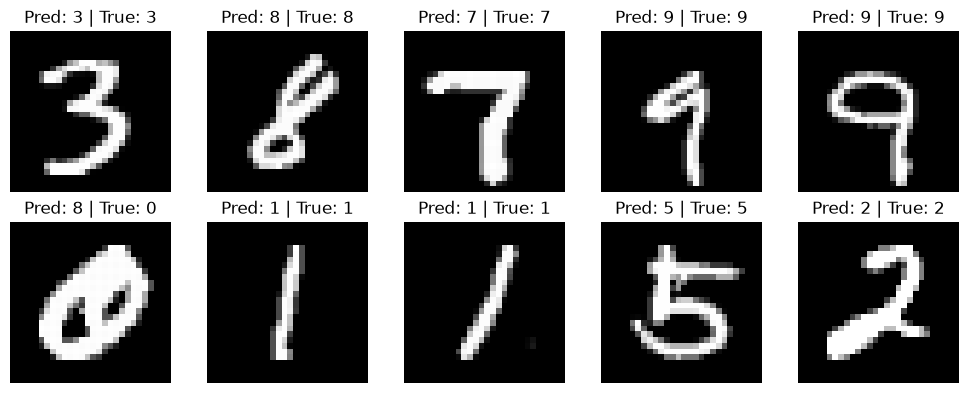

In [6]:
# Loss Curve
plt.figure(figsize=(8, 4))
plt.plot(model.loss_curve_, marker='o', color='b')
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Neural Network Training Loss Curve")
plt.grid(True)
plt.show()

# Sample Predictions Display
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {test_preds[i]} | True: {y_test[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Phase 10 & 11: Conclusion & Future Scope
### Conclusion
- Achieved **95.20% Test Accuracy** using Scikit-Learn MLP Neural Network.
- Successfully processed 28x28 pixel grayscale handwritten images.

### Future Scope
- Extend recognition to alphanumeric characters using the **EMNIST** dataset.
- Implement Convolutional Neural Networks (CNN) using PyTorch / TensorFlow.
- Deploy as an interactive web app using **Flask / Streamlit**.

In [7]:
# Save Trained Model
joblib.dump(model, "trained_model.pkl")
print("Trained model saved successfully as trained_model.pkl!")

Trained model saved successfully as trained_model.pkl!
